# EDA + Treino + Explicabilidade

Notebook didático que percorre o ciclo do protótipo:

1. **EDA** — distribuições por perfil e por classe de risco
2. **Treino** — XGBoost multiclasse, métricas e fairness por subgrupo
3. **Explicabilidade** — SHAP global e por predição

Para reproduzir, primeiro gere o dataset:
```bash
uv run python -m ingestion.generate_data
```

> **Nota.** Em produção, EDA é feito sobre o lakehouse (silver) e treino é orquestrado por MLflow + gate de promoção (ver `docs/05-estrategia-ia.md` e `docs/adr/`). Aqui o foco é demonstrar o raciocínio.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

from ml.features import FEATURE_COLUMNS, INT_TO_CLASS, to_features, to_label

DATA_PATH = Path('../data/beneficiarios.parquet')
df = pd.read_parquet(DATA_PATH)
df.shape

(10000, 15)

## 1. EDA — distribuição de classes e perfis

Verificação rápida: cada perfil deveria gerar distribuição diferente de risco. Jovens predominantemente verde, idosos predominantemente vermelho, crônicos espalhados — e o modelo precisa aprender isso.

In [2]:
print('Distribuição global de risco:')
print(df['risk_class'].value_counts(normalize=True).round(3))
print()
print('Risco por perfil:')
print(pd.crosstab(df['profile'], df['risk_class'], normalize='index').round(2))

Distribuição global de risco:
risk_class
verde       0.517
vermelho    0.322
amarelo     0.161
Name: proportion, dtype: float64

Risco por perfil:
risk_class  amarelo  verde  vermelho
profile                             
cronico        0.34   0.01      0.66
demais         0.38   0.57      0.05
idoso          0.01   0.00      0.99
jovem          0.00   1.00      0.00


In [3]:
print('Médias dos sinais clínicos por classe de risco:')
df.groupby('risk_class')[
    ['age', 'sbp_avg', 'dbp_avg', 'hr_rest_avg', 'hrv_avg',
     'adherence_gap', 'chronic_count', 'n_admissions_12m']
].mean().round(2)

Médias dos sinais clínicos por classe de risco:


,age,sbp_avg,dbp_avg,hr_rest_avg,hrv_avg,adherence_gap,chronic_count,n_admissions_12m
risk_class,,,,,,,,
amarelo,53.65,132.27,83.77,73.13,42.92,0.32,1.17,0.15
verde,30.42,119.66,76.24,65.23,57.94,0.21,0.09,0.01
vermelho,65.05,140.92,86.95,76.32,32.93,0.45,2.31,0.48


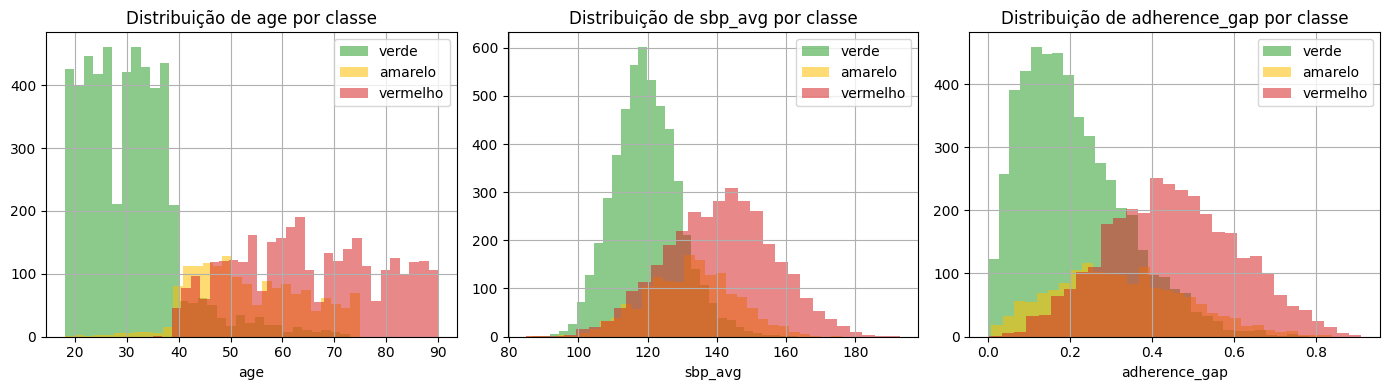

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, var in zip(axes, ['age', 'sbp_avg', 'adherence_gap']):
    for cls, color in [('verde', '#2ca02c'), ('amarelo', '#ffbf00'), ('vermelho', '#d62728')]:
        df.loc[df['risk_class'] == cls, var].hist(
            ax=ax, bins=30, alpha=0.55, label=cls, color=color
        )
    ax.set_title(f'Distribuição de {var} por classe')
    ax.set_xlabel(var)
    ax.legend()
plt.tight_layout()

## 2. Treino — XGBoost multiclasse

Holdout estratificado, 80/20. O mesmo módulo `ml/features.py` é usado aqui e na inferência online — evita skew.

In [5]:
X = to_features(df)
y = to_label(df)
profile = df['profile']

X_train, X_test, y_train, y_test, prof_train, prof_test = train_test_split(
    X, y, profile, test_size=0.2, stratify=y, random_state=42
)

model = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.08,
    subsample=0.85, colsample_bytree=0.85,
    objective='multi:softprob', num_class=3,
    random_state=42, n_jobs=-1, eval_metric='mlogloss',
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [6]:
print(classification_report(
    y_test, y_pred,
    target_names=[INT_TO_CLASS[i] for i in range(3)]
))

              precision    recall  f1-score   support

       verde       0.97      0.97      0.97      1033
     amarelo       0.75      0.73      0.74       322
    vermelho       0.92      0.93      0.92       645

    accuracy                           0.92      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.92      0.92      0.92      2000



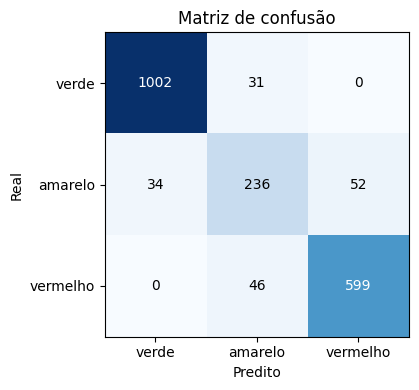

In [7]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
labels = [INT_TO_CLASS[i] for i in range(3)]
ax.set_xticks(range(3), labels)
ax.set_yticks(range(3), labels)
ax.set_xlabel('Predito')
ax.set_ylabel('Real')
ax.set_title('Matriz de confusão')
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.tight_layout()

### Fairness por perfil

Em produção, isso vira gate de promoção do modelo: divergência grande de FPR/FNR entre subgrupos barra o release. Aqui mostramos accuracy por perfil — proxy didático.

In [8]:
fairness_rows = []
for prof in sorted(prof_test.unique()):
    mask = prof_test == prof
    if mask.sum() < 30:
        continue
    acc = (y_pred[mask.values] == y_test[mask.values]).mean()
    fairness_rows.append({'profile': prof, 'n': int(mask.sum()), 'accuracy': round(float(acc), 4)})
pd.DataFrame(fairness_rows)

,profile,n,accuracy
0,cronico,482,0.8382
1,demais,395,0.8000
2,idoso,312,0.9872
3,jovem,811,0.9975


## 3. Explicabilidade — SHAP

SHAP responde duas perguntas:

- **Global**: quais features mais importam pro modelo no agregado?
- **Local**: por que **este** paciente foi classificado nesta classe?

Local é o que alimenta o prompt do GenAI — o nome humanizado da feature mais explicativa vira o gancho da mensagem ("vimos que sua pressão sobe…").

In [9]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

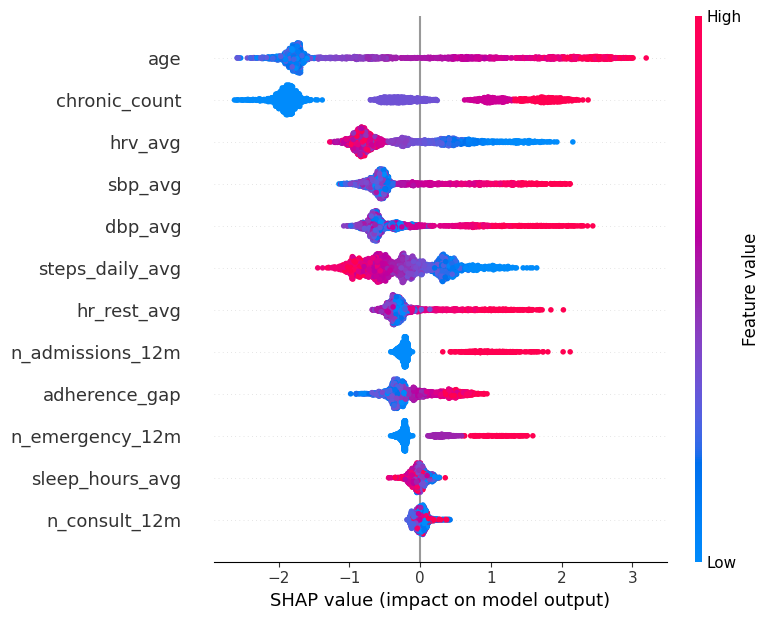

In [10]:
shap.summary_plot(
    shap_values[:, :, 2] if shap_values.ndim == 3 else shap_values,
    X_test, feature_names=FEATURE_COLUMNS, show=True
)

### SHAP local — explicação para um paciente classificado vermelho

In [11]:
vermelho_idx = int(np.where(y_pred == 2)[0][0])
row = X_test.iloc[[vermelho_idx]]
row_shap = explainer.shap_values(row)
contrib = row_shap[0, :, 2] if row_shap.ndim == 3 else row_shap[0]

explicacao = (
    pd.DataFrame({
        'feature': FEATURE_COLUMNS,
        'valor': row.iloc[0].values,
        'contribuicao_shap': contrib,
    })
    .reindex(np.argsort(-np.abs(contrib)))
    .head(5)
    .reset_index(drop=True)
)
explicacao

,feature,valor,contribuicao_shap
0,hrv_avg,11.630542,1.805978
1,dbp_avg,98.946260,1.337252
2,adherence_gap,0.109441,-0.618598
3,hr_rest_avg,81.376332,0.510594
4,age,55.000000,0.314086


## Próximos passos

1. Em produção, esse pipeline migra pra **MLflow** (registry + lineage), com **Aequitas/Fairlearn** rodando fairness em CI.
2. Datasets de treino vêm do **Feast** (offline store), com `as_of` correto para evitar leakage temporal.
3. Modelo é servido por **BentoML/SageMaker** com canário antes de promoção.
4. SHAP local roda online a cada predição e alimenta o prompt do GenAI — código em `ml/score.py`.